# Lie Groups & Lie Algebras: SO(3) and SE(3)
## A Computational Introduction for Robotics and Geometric Mechanics

---

This notebook provides a rigorous, first-principles development of the Lie groups
**SO(3)** (rotations in 3D) and **SE(3)** (rigid body transformations), together with
their associated Lie algebras **so(3)** and **se(3)**.

### Why Lie Groups in Robotics?

Rigid body motions — rotations and translations — are the bread and butter of
robotics, computer vision, and spacecraft attitude control. The set of all rotations
forms a **group** under matrix multiplication, not a vector space. Naively adding or
interpolating rotation matrices breaks their structure (the result may no longer be a
valid rotation). Lie theory gives us the mathematical machinery to:

- **Parameterize** rotations and rigid motions in a minimal, singularity-aware way
- **Differentiate** and **optimize** on curved spaces (manifolds)
- **Compose** transformations and compute Jacobians for robot kinematics

### Prerequisites

- Linear algebra: matrix multiplication, determinants, eigenvalues
- Matrix exponential: $e^A = I + A + \frac{A^2}{2!} + \cdots$
- Basic multivariable calculus

### References

1. Murray, Li & Sastry, *A Mathematical Introduction to Robotic Manipulation* (1994)
2. Chirikjian, *Stochastic Models, Information Theory, and Lie Groups*, Vol. 1–2
3. Sola, Deray & Atchuthan, *A micro Lie theory for state estimation in robotics* (2018)
4. Lynch & Park, *Modern Robotics: Mechanics, Planning, and Control* (2017)

In [6]:
%matplotlib inline

import numpy as np
from numpy.linalg import norm, det, inv, eig, matrix_rank
from scipy.linalg import expm, logm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2
})

print("All imports successful.")

All imports successful.


### Constants and Configuration

In [7]:
# =============================================================================
# Constants
# =============================================================================
TOLERANCE = 1e-10          # Numerical tolerance for verification checks
PASS_THRESHOLD = 1e-8      # Threshold for PASS/FAIL verification
PI = np.pi
SEED = 42                  # Reproducibility seed

np.random.seed(SEED)

# Color palette
C_PRIMARY   = "steelblue"
C_SECONDARY = "coral"
C_TERTIARY  = "seagreen"
C_ACCENT    = "goldenrod"
C_CMAP      = "viridis"

print(f"Constants defined. Tolerance = {TOLERANCE:.0e}, Seed = {SEED}")

Constants defined. Tolerance = 1e-10, Seed = 42


---
## 2. Group Theory Foundations

A **group** $(G, \cdot)$ is a set $G$ together with a binary operation $\cdot$ satisfying:

| Axiom | Statement |
|-------|-----------|
| **Closure** | $\forall\, a, b \in G: \; a \cdot b \in G$ |
| **Associativity** | $\forall\, a, b, c \in G: \; (a \cdot b) \cdot c = a \cdot (b \cdot c)$ |
| **Identity** | $\exists\, e \in G: \; e \cdot a = a \cdot e = a$ |
| **Inverse** | $\forall\, a \in G, \; \exists\, a^{-1}: \; a \cdot a^{-1} = e$ |

### Important Matrix Groups

| Group | Definition | Dimension |
|-------|-----------|-----------|
| $GL(n)$ | Invertible $n \times n$ matrices ($\det A \neq 0$) | $n^2$ |
| $O(n)$ | Orthogonal matrices ($R^T R = I$) | $n(n-1)/2$ |
| $SO(n)$ | Special orthogonal ($R^T R = I$, $\det R = 1$) | $n(n-1)/2$ |
| $SE(n)$ | Special Euclidean (rotation + translation) | $n(n+1)/2$ |

A **matrix Lie group** is a group of matrices that is also a smooth manifold — you can
take derivatives and do calculus on it.

In [8]:
# =============================================================================
# Section 2: Verify Group Axioms for SO(3)
# =============================================================================

def random_rotation():
    """Generate a random rotation matrix via QR decomposition.

    Returns:
        R: Random rotation matrix.
        Shape: (3, 3)
    """
    A = np.random.randn(3, 3)
    Q, R_upper = np.linalg.qr(A)
    # Ensure det = +1
    Q = Q @ np.diag(np.sign(np.diag(R_upper)))
    if det(Q) < 0:
        Q[:, 0] *= -1
    return Q

# Generate random rotation matrices
R1 = random_rotation()
R2 = random_rotation()
R3 = random_rotation()

print("=== Verifying Group Axioms for SO(3) ===\n")

# 1. Closure: R1 @ R2 should be in SO(3)
R12 = R1 @ R2
ortho_err_closure = norm(R12.T @ R12 - np.eye(3))
det_err_closure = abs(det(R12) - 1.0)
status = "PASS" if ortho_err_closure < PASS_THRESHOLD else "FAIL"
print(f"Closure (R1 @ R2 in SO(3)):     orthogonality error = {ortho_err_closure:.2e}, "
      f"det error = {det_err_closure:.2e} [{status}]")

# 2. Associativity: (R1 @ R2) @ R3 == R1 @ (R2 @ R3)
assoc_err = norm((R1 @ R2) @ R3 - R1 @ (R2 @ R3))
status = "PASS" if assoc_err < PASS_THRESHOLD else "FAIL"
print(f"Associativity:                   max error = {assoc_err:.2e} [{status}]")

# 3. Identity: I @ R == R @ I == R
I3 = np.eye(3)
id_err = max(norm(I3 @ R1 - R1), norm(R1 @ I3 - R1))
status = "PASS" if id_err < PASS_THRESHOLD else "FAIL"
print(f"Identity (I @ R = R):            max error = {id_err:.2e} [{status}]")

# 4. Inverse: R @ R^T == I (for orthogonal matrices, R^{-1} = R^T)
inv_err = norm(R1 @ R1.T - I3)
status = "PASS" if inv_err < PASS_THRESHOLD else "FAIL"
print(f"Inverse (R @ R^T = I):           max error = {inv_err:.2e} [{status}]")

# Also: the group is NOT commutative (non-abelian)
comm_diff = norm(R1 @ R2 - R2 @ R1)
print(f"\nNon-commutativity |R1R2 - R2R1| = {comm_diff:.6f}  (non-zero => non-abelian)")

=== Verifying Group Axioms for SO(3) ===

Closure (R1 @ R2 in SO(3)):     orthogonality error = 3.66e-16, det error = 0.00e+00 [PASS]
Associativity:                   max error = 1.76e-16 [PASS]
Identity (I @ R = R):            max error = 0.00e+00 [PASS]
Inverse (R @ R^T = I):           max error = 3.63e-16 [PASS]

Non-commutativity |R1R2 - R2R1| = 2.474554  (non-zero => non-abelian)


---
## 3. SO(3): The Rotation Group

The **special orthogonal group** in 3D is:

$$
\boxed{SO(3) = \{ R \in \mathbb{R}^{3 \times 3} \mid R^T R = I, \; \det R = 1 \}}
$$

### Constraints

A $3 \times 3$ matrix has 9 entries. The constraint $R^T R = I$ gives 6 independent
equations (the upper triangle of a symmetric matrix), leaving $9 - 6 = 3$ degrees
of freedom. The constraint $\det R = 1$ is automatically satisfied once $R^T R = I$ and
we pick the correct sign.

### Axis-Angle Representation

Every rotation can be described by:
- A unit axis $\hat{\omega} \in \mathbb{R}^3$, $\|\hat{\omega}\| = 1$
- An angle $\theta \in [0, \pi]$

The rotation by angle $\theta$ about axis $\hat{\omega}$ is:

$$
R = e^{[\hat{\omega}]_\times \theta}
$$

where $[\omega]_\times$ is the **skew-symmetric (hat) matrix**.

### Derivation from the Matrix ODE

Consider a point $p(t)$ rotating about axis $\hat{\omega}$ with angular velocity
$\dot{\theta}$. Its trajectory satisfies:

$$
\dot{p} = \omega \times p = [\omega]_\times \, p
$$

If $p(t) = R(t) \, p(0)$, then $\dot{R} = [\omega]_\times R$ with $R(0) = I$.
The solution to this linear matrix ODE is:

$$
\boxed{R(t) = e^{[\omega]_\times t}}
$$

In [9]:
# =============================================================================
# Section 3: SO(3) - Rotation Matrices and Axis-Angle
# =============================================================================

def is_valid_rotation(R):
    """Check if a matrix is a valid rotation matrix.

    Args:
        R: Matrix to check.
            Shape: (3, 3)

    Returns:
        ortho_err: Orthogonality error ||R^T R - I||.
        det_err: Determinant error |det(R) - 1|.
        is_valid: True if both errors are below TOLERANCE.
    """
    ortho_err = norm(R.T @ R - np.eye(3))
    det_err = abs(det(R) - 1.0)
    is_valid = (ortho_err < PASS_THRESHOLD) and (det_err < PASS_THRESHOLD)
    return ortho_err, det_err, is_valid

# Demonstrate axis-angle: rotation about z-axis by 90 degrees
theta = PI / 2
Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
])

ortho_err, det_err, valid = is_valid_rotation(Rz)
print(f"Rz(90 deg):\n{np.round(Rz, 6)}\n")
print(f"Orthogonality error: {ortho_err:.2e}")
print(f"Determinant error:   {det_err:.2e}")
print(f"Valid SO(3): {valid}")

# Verify: rotating [1,0,0] by 90 deg about z gives [0,1,0]
p = np.array([1, 0, 0])
p_rot = Rz @ p
print(f"\nRz @ [1,0,0] = {np.round(p_rot, 6)}  (expected [0, 1, 0])")

Rz(90 deg):
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

Orthogonality error: 0.00e+00
Determinant error:   0.00e+00
Valid SO(3): True

Rz @ [1,0,0] = [0. 1. 0.]  (expected [0, 1, 0])


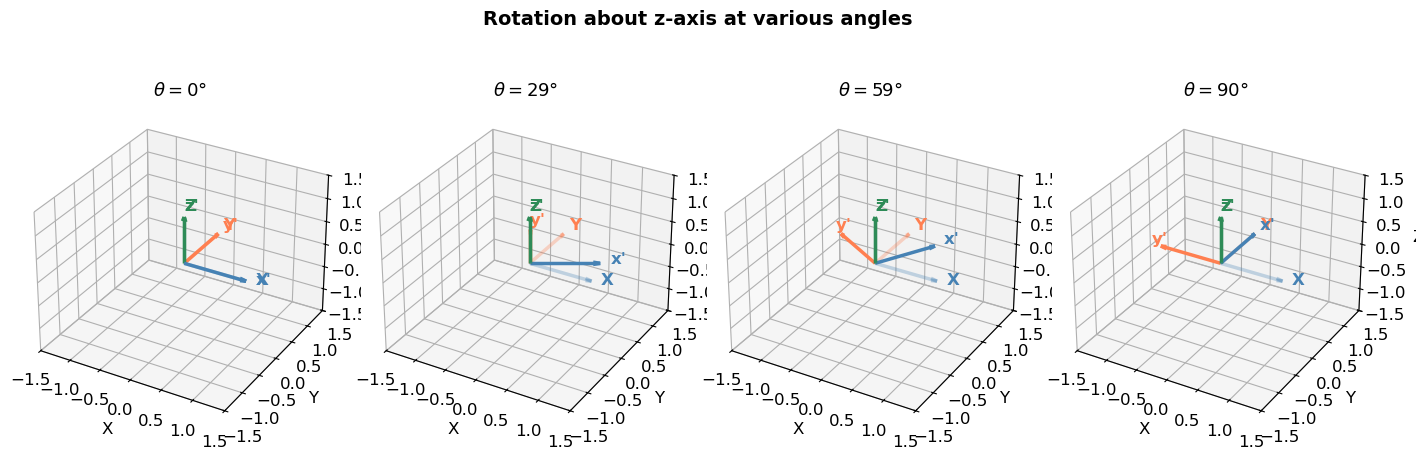

In [10]:
# =============================================================================
# Section 3: Visualize rotation action on a cube
# =============================================================================

def plot_frame(ax, R, origin=np.zeros(3), length=1.0, labels=('x', 'y', 'z'),
               colors=None, alpha=1.0):
    """Plot a coordinate frame defined by rotation R at a given origin.

    Args:
        ax: Matplotlib 3D axis.
        R: Rotation matrix defining the frame.
            Shape: (3, 3)
        origin: Origin of the frame.
            Shape: (3,)
        length: Length of the axis arrows.
        labels: Tuple of axis labels.
        colors: Tuple of colors for each axis.
        alpha: Transparency.
    """
    if colors is None:
        colors = (C_PRIMARY, C_SECONDARY, C_TERTIARY)
    for i in range(3):
        ax.quiver(*origin, *(R[:, i] * length),
                  color=colors[i], alpha=alpha, arrow_length_ratio=0.1, linewidth=2.5)
        ax.text(*(origin + R[:, i] * length * 1.15), labels[i],
                color=colors[i], fontsize=12, fontweight='bold')

fig = plt.figure(figsize=(14, 5))

# Create several rotations to visualize
angles = [0, PI/6, PI/3, PI/2]
axis = np.array([0, 0, 1])  # z-axis

for idx, angle in enumerate(angles):
    ax = fig.add_subplot(1, 4, idx + 1, projection='3d')
    # Rotation using Rodrigues (we'll derive this later; for now use expm)
    omega_hat = np.array([[0, -axis[2], axis[1]],
                          [axis[2], 0, -axis[0]],
                          [-axis[1], axis[0], 0]])
    R = expm(omega_hat * angle)

    plot_frame(ax, np.eye(3), labels=('X', 'Y', 'Z'), alpha=0.3)
    plot_frame(ax, R, labels=("x'", "y'", "z'"))

    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_zlim([-1.5, 1.5])
    ax.set_title(f"$\\theta = {int(np.degrees(angle))}°$", fontsize=13)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.suptitle("Rotation about z-axis at various angles", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. The Lie Algebra $\mathfrak{so}(3)$

The **Lie algebra** of SO(3) is the tangent space at the identity — the set of all
$3 \times 3$ skew-symmetric matrices:

$$
\boxed{\mathfrak{so}(3) = \{ \Omega \in \mathbb{R}^{3 \times 3} \mid \Omega^T = -\Omega \}}
$$

### The Hat and Vee Operators

The **hat** map $[\cdot]_\times : \mathbb{R}^3 \to \mathfrak{so}(3)$ converts a 3-vector to a
skew-symmetric matrix:

$$
[\omega]_\times = \hat{\omega} = \begin{bmatrix} 0 & -\omega_3 & \omega_2 \\ \omega_3 & 0 & -\omega_1 \\ -\omega_2 & \omega_1 & 0 \end{bmatrix}
$$

The **vee** map $[\cdot]^\vee : \mathfrak{so}(3) \to \mathbb{R}^3$ is the inverse.

Key property: $[\omega]_\times v = \omega \times v$ (cross product).

### The Lie Bracket

The Lie bracket on $\mathfrak{so}(3)$ is the matrix commutator:

$$
[A, B] = AB - BA
$$

This corresponds to the cross product: $[\hat{a}, \hat{b}] = \widehat{a \times b}$.

In [11]:
# =============================================================================
# Section 4: Hat and Vee Operators for so(3)
# =============================================================================

def hat3(omega):
    """Hat (wedge) operator: R^3 -> so(3) skew-symmetric matrix.

    Maps a 3-vector to its corresponding skew-symmetric matrix such that
    hat3(omega) @ v == np.cross(omega, v).

    Args:
        omega: Angular velocity or rotation vector.
            Shape: (3,)

    Returns:
        Omega_hat: Skew-symmetric matrix.
            Shape: (3, 3)
    """
    x, y, z = omega
    return np.array([
        [ 0, -z,  y],
        [ z,  0, -x],
        [-y,  x,  0]
    ])


def vee3(Omega):
    """Vee operator: so(3) skew-symmetric matrix -> R^3.

    Inverse of the hat operator.

    Args:
        Omega: Skew-symmetric matrix.
            Shape: (3, 3)

    Returns:
        omega: 3-vector extracted from the skew-symmetric matrix.
            Shape: (3,)
    """
    return np.array([Omega[2, 1], Omega[0, 2], Omega[1, 0]])


# Verify hat and vee are inverses
omega_test = np.array([1.0, 2.0, 3.0])
Omega_test = hat3(omega_test)

print("omega =", omega_test)
print(f"hat(omega) =\n{Omega_test}\n")
print(f"vee(hat(omega)) = {vee3(Omega_test)}")

# Verify skew-symmetry
skew_err = norm(Omega_test + Omega_test.T)
status = "PASS" if skew_err < PASS_THRESHOLD else "FAIL"
print(f"\nSkew-symmetry ||Omega + Omega^T||: max relative error = {skew_err:.2e} [{status}]")

# Verify hat(omega) @ v == cross(omega, v)
v_test = np.array([4.0, 5.0, 6.0])
cross_err = norm(hat3(omega_test) @ v_test - np.cross(omega_test, v_test))
status = "PASS" if cross_err < PASS_THRESHOLD else "FAIL"
print(f"Cross product identity:          max relative error = {cross_err:.2e} [{status}]")

# Verify hat-vee roundtrip
roundtrip_err = norm(vee3(hat3(omega_test)) - omega_test)
status = "PASS" if roundtrip_err < PASS_THRESHOLD else "FAIL"
print(f"Hat-vee roundtrip:               max relative error = {roundtrip_err:.2e} [{status}]")

omega = [1. 2. 3.]
hat(omega) =
[[ 0. -3.  2.]
 [ 3.  0. -1.]
 [-2.  1.  0.]]

vee(hat(omega)) = [1. 2. 3.]

Skew-symmetry ||Omega + Omega^T||: max relative error = 0.00e+00 [PASS]
Cross product identity:          max relative error = 0.00e+00 [PASS]
Hat-vee roundtrip:               max relative error = 0.00e+00 [PASS]


In [12]:
# =============================================================================
# Section 4: Lie Bracket and its Relation to Cross Product
# =============================================================================

def lie_bracket_so3(A, B):
    """Compute the Lie bracket [A, B] = AB - BA for so(3) elements.

    Args:
        A: Skew-symmetric matrix.
            Shape: (3, 3)
        B: Skew-symmetric matrix.
            Shape: (3, 3)

    Returns:
        Bracket: The matrix commutator AB - BA.
            Shape: (3, 3)
    """
    return A @ B - B @ A

a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 1.0, 0.0])

bracket = lie_bracket_so3(hat3(a), hat3(b))
cross = np.cross(a, b)

print(f"a = {a}")
print(f"b = {b}")
print(f"\n[hat(a), hat(b)] =\n{bracket}\n")
print(f"vee([hat(a), hat(b)]) = {vee3(bracket)}")
print(f"a x b                 = {cross}")

bracket_err = norm(vee3(bracket) - cross)
status = "PASS" if bracket_err < PASS_THRESHOLD else "FAIL"
print(f"\nLie bracket == cross product:     max relative error = {bracket_err:.2e} [{status}]")

# Verify Jacobi identity: [A,[B,C]] + [B,[C,A]] + [C,[A,B]] = 0
c = np.array([0.0, 0.0, 1.0])
A_hat, B_hat, C_hat = hat3(a), hat3(b), hat3(c)
jacobi = (lie_bracket_so3(A_hat, lie_bracket_so3(B_hat, C_hat)) +
          lie_bracket_so3(B_hat, lie_bracket_so3(C_hat, A_hat)) +
          lie_bracket_so3(C_hat, lie_bracket_so3(A_hat, B_hat)))
jacobi_err = norm(jacobi)
status = "PASS" if jacobi_err < PASS_THRESHOLD else "FAIL"
print(f"Jacobi identity:                 max relative error = {jacobi_err:.2e} [{status}]")

a = [1. 0. 0.]
b = [0. 1. 0.]

[hat(a), hat(b)] =
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  0.]]

vee([hat(a), hat(b)]) = [0. 0. 1.]
a x b                 = [0. 0. 1.]

Lie bracket == cross product:     max relative error = 0.00e+00 [PASS]
Jacobi identity:                 max relative error = 0.00e+00 [PASS]


---
## 5. Exponential and Logarithmic Maps for SO(3)

### Rodrigues' Formula — Derivation

Given $\omega = \theta \hat{\omega}$ where $\|\hat{\omega}\| = 1$, we want a closed
form for:

$$
e^{[\omega]_\times} = e^{\theta [\hat{\omega}]_\times}
= I + \theta [\hat{\omega}]_\times + \frac{\theta^2}{2!} [\hat{\omega}]_\times^2 + \cdots
$$

Key observation: for a unit-norm skew-symmetric matrix $K = [\hat{\omega}]_\times$:

$$
K^3 = -K, \quad K^4 = -K^2, \quad K^5 = K, \quad \ldots
$$

Collecting terms with the same power pattern:

$$
e^{\theta K} = I + \left(\theta - \frac{\theta^3}{3!} + \cdots\right) K
+ \left(\frac{\theta^2}{2!} - \frac{\theta^4}{4!} + \cdots\right) K^2
$$

Recognizing the Taylor series for $\sin$ and $1 - \cos$:

$$
\boxed{e^{[\omega]_\times} = I + \frac{\sin\theta}{\theta} [\omega]_\times + \frac{1 - \cos\theta}{\theta^2} [\omega]_\times^2}
$$

This is **Rodrigues' rotation formula**.

### Logarithmic Map

Given $R \in SO(3)$, find $\omega$ such that $e^{[\omega]_\times} = R$.

The angle is recovered from the trace:

$$
\theta = \arccos\left(\frac{\text{tr}(R) - 1}{2}\right)
$$

The axis (for $\theta \neq 0, \pi$) is:

$$
[\omega]_\times = \frac{\theta}{2 \sin\theta}(R - R^T)
$$

In [13]:
# =============================================================================
# Section 5: Exponential Map — Rodrigues' Formula
# =============================================================================

def exp_so3(omega):
    """Exponential map from so(3) to SO(3) via Rodrigues' formula.

    Computes R = exp([omega]_x) = I + (sin(theta)/theta) * [omega]_x
                                    + ((1-cos(theta))/theta^2) * [omega]_x^2

    Args:
        omega: Rotation vector (axis * angle).
            Shape: (3,)

    Returns:
        R: Rotation matrix in SO(3).
            Shape: (3, 3)
    """
    theta = norm(omega)
    if theta < TOLERANCE:
        # First-order approximation for small angles
        return np.eye(3) + hat3(omega)

    K = hat3(omega / theta)  # Unit skew-symmetric
    K2 = K @ K
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K2
    return R


def log_so3(R):
    """Logarithmic map from SO(3) to so(3).

    Computes omega such that exp([omega]_x) = R.

    Args:
        R: Rotation matrix.
            Shape: (3, 3)

    Returns:
        omega: Rotation vector (axis * angle).
            Shape: (3,)
    """
    cos_theta = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    if theta < TOLERANCE:
        # Small angle: R ~ I + [omega]_x, so omega ~ vee(R - I)
        return vee3(R - np.eye(3))

    if abs(theta - PI) < TOLERANCE:
        # theta ~ pi: need special handling
        # Find the column of (R + I) with the largest norm
        M = R + np.eye(3)
        col_norms = [norm(M[:, i]) for i in range(3)]
        k = np.argmax(col_norms)
        omega_hat = M[:, k] / norm(M[:, k])
        return omega_hat * theta

    # General case
    omega_hat_skew = (theta / (2 * np.sin(theta))) * (R - R.T)
    return vee3(omega_hat_skew)


# === Verification ===
print("=== Exponential Map Verification ===\n")

# Test 1: 90 deg about z-axis
omega_z90 = np.array([0, 0, PI/2])
R_z90 = exp_so3(omega_z90)
R_z90_expected = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]], dtype=float)
err1 = norm(R_z90 - R_z90_expected)
status = "PASS" if err1 < PASS_THRESHOLD else "FAIL"
print(f"exp([0,0,pi/2]_x) = Rz(90):     max relative error = {err1:.2e} [{status}]")

# Test 2: Compare with scipy expm
omega_rand = np.array([0.5, -0.3, 0.7])
R_rodrigues = exp_so3(omega_rand)
R_expm = expm(hat3(omega_rand))
err2 = norm(R_rodrigues - R_expm)
status = "PASS" if err2 < PASS_THRESHOLD else "FAIL"
print(f"Rodrigues vs scipy expm:         max relative error = {err2:.2e} [{status}]")

# Test 3: Result is valid SO(3)
ortho_err, det_err, valid = is_valid_rotation(R_rodrigues)
status = "PASS" if valid else "FAIL"
print(f"exp_so3 produces valid SO(3):    ortho={ortho_err:.2e}, det={det_err:.2e} [{status}]")

# Test 4: Small angle
omega_small = np.array([1e-12, 2e-12, 3e-12])
R_small = exp_so3(omega_small)
_, _, valid_small = is_valid_rotation(R_small)
status = "PASS" if valid_small else "FAIL"
print(f"Small angle stability:           [{status}]")

=== Exponential Map Verification ===

exp([0,0,pi/2]_x) = Rz(90):     max relative error = 1.57e-16 [PASS]
Rodrigues vs scipy expm:         max relative error = 2.01e-16 [PASS]
exp_so3 produces valid SO(3):    ortho=1.33e-16, det=2.22e-16 [PASS]
Small angle stability:           [PASS]


In [14]:
# =============================================================================
# Section 5: Log Map Verification and Inverse Relationship
# =============================================================================

print("=== Logarithmic Map Verification ===\n")

# Test: exp_so3(log_so3(R)) == R
np.random.seed(SEED)
n_tests = 5
print("--- exp(log(R)) == R ---")
for i in range(n_tests):
    R_test = random_rotation()
    omega_recovered = log_so3(R_test)
    R_reconstructed = exp_so3(omega_recovered)
    err = norm(R_reconstructed - R_test)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: exp(log(R)) roundtrip: max relative error = {err:.2e} [{status}]")

# Test: log_so3(exp_so3(omega)) == omega
print("\n--- log(exp(omega)) == omega ---")
np.random.seed(SEED + 1)
for i in range(n_tests):
    omega_test = np.random.randn(3) * 0.8  # Keep away from pi boundary
    R_test = exp_so3(omega_test)
    omega_recovered = log_so3(R_test)
    err = norm(omega_recovered - omega_test)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: log(exp(omega)) roundtrip: max relative error = {err:.2e} [{status}]")

=== Logarithmic Map Verification ===

--- exp(log(R)) == R ---
  Test 1: exp(log(R)) roundtrip: max relative error = 6.66e-16 [PASS]
  Test 2: exp(log(R)) roundtrip: max relative error = 2.13e-14 [PASS]
  Test 3: exp(log(R)) roundtrip: max relative error = 5.60e-16 [PASS]
  Test 4: exp(log(R)) roundtrip: max relative error = 2.85e-16 [PASS]
  Test 5: exp(log(R)) roundtrip: max relative error = 7.73e-15 [PASS]

--- log(exp(omega)) == omega ---
  Test 1: log(exp(omega)) roundtrip: max relative error = 2.78e-17 [PASS]
  Test 2: log(exp(omega)) roundtrip: max relative error = 1.11e-16 [PASS]
  Test 3: log(exp(omega)) roundtrip: max relative error = 5.55e-17 [PASS]
  Test 4: log(exp(omega)) roundtrip: max relative error = 7.85e-17 [PASS]
  Test 5: log(exp(omega)) roundtrip: max relative error = 5.09e-16 [PASS]


In [15]:
# =============================================================================
# Section 5: Gradient Check for Exponential Map
# =============================================================================

def gradient_check_exp_so3(omega, dt=1e-7):
    """Verify d/dt exp(t*omega)|_{t=1} == hat(omega) @ exp(omega).

    The derivative of the exponential map satisfies:
        d/dt exp(t * omega) = hat(omega) @ exp(t * omega)

    Args:
        omega: Rotation vector.
            Shape: (3,)
        dt: Step size for finite difference.

    Returns:
        err: Maximum absolute error between numerical and analytical derivatives.
    """
    # Numerical derivative via finite difference
    R_plus = exp_so3(omega * (1 + dt))
    R_minus = exp_so3(omega * (1 - dt))
    dR_numerical = (R_plus - R_minus) / (2 * dt)

    # Analytical derivative
    dR_analytical = hat3(omega) @ exp_so3(omega)

    return norm(dR_numerical - dR_analytical)

print("=== Gradient Check: d/dt exp(t*omega) vs hat(omega) @ exp(t*omega) ===\n")
np.random.seed(SEED)
for i in range(5):
    omega_test = np.random.randn(3) * 0.8
    err = gradient_check_exp_so3(omega_test)
    status = "PASS" if err < 1e-5 else "FAIL"
    print(f"  Test {i+1}: gradient error = {err:.2e} [{status}]")

=== Gradient Check: d/dt exp(t*omega) vs hat(omega) @ exp(t*omega) ===

  Test 1: gradient error = 7.04e-10 [PASS]
  Test 2: gradient error = 5.81e-10 [PASS]
  Test 3: gradient error = 1.76e-09 [PASS]
  Test 4: gradient error = 7.99e-10 [PASS]
  Test 5: gradient error = 2.42e-09 [PASS]


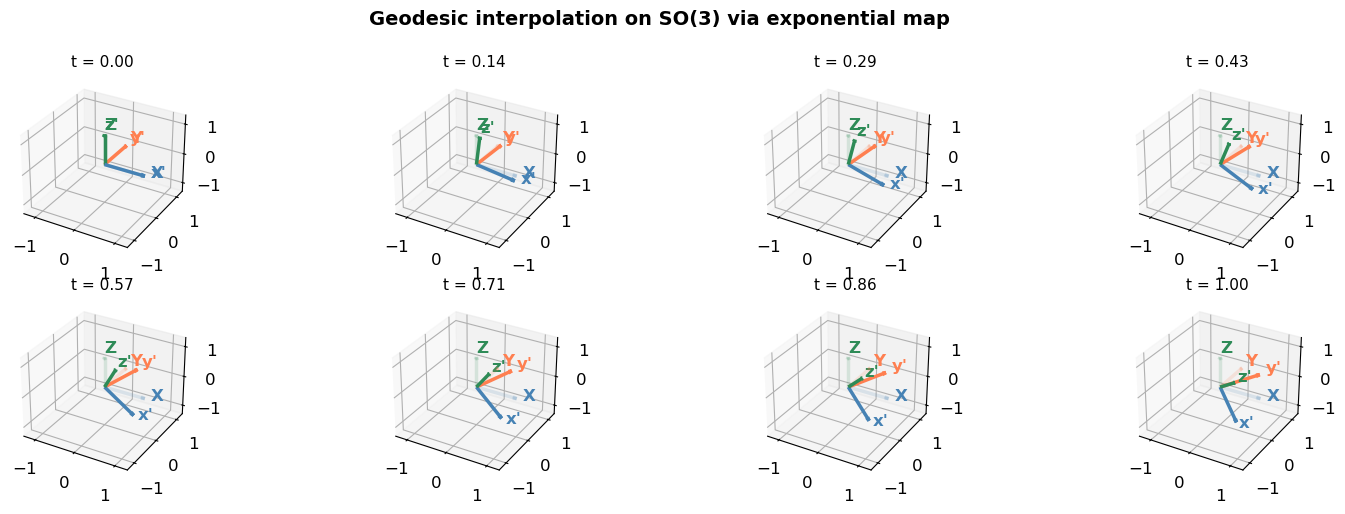

In [16]:
# =============================================================================
# Section 5: Visualization — Interpolation on SO(3)
# =============================================================================

# Interpolate between identity and a target rotation using the exponential map
R_target = exp_so3(np.array([0.3, 0.8, -0.5]))
omega_target = log_so3(R_target)

t_values = np.linspace(0, 1, 8)

fig = plt.figure(figsize=(16, 5))
for idx, t in enumerate(t_values):
    ax = fig.add_subplot(2, 4, idx + 1, projection='3d')
    R_interp = exp_so3(t * omega_target)
    plot_frame(ax, R_interp, labels=("x'", "y'", "z'"))
    plot_frame(ax, np.eye(3), alpha=0.15, labels=('X', 'Y', 'Z'))
    ax.set_xlim([-1.3, 1.3])
    ax.set_ylim([-1.3, 1.3])
    ax.set_zlim([-1.3, 1.3])
    ax.set_title(f"t = {t:.2f}", fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

plt.suptitle("Geodesic interpolation on SO(3) via exponential map", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. SE(3): The Rigid Body Motion Group

A **rigid body transformation** in 3D combines rotation and translation. It is
represented as a $4 \times 4$ homogeneous transformation matrix:

$$
T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix} \in SE(3)
$$

where $R \in SO(3)$ and $p \in \mathbb{R}^3$.

$$
\boxed{SE(3) = \left\{ \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix} \,\middle|\, R \in SO(3), \; p \in \mathbb{R}^3 \right\}}
$$

### Group Operations

- **Composition**: $T_1 T_2 = \begin{bmatrix} R_1 R_2 & R_1 p_2 + p_1 \\ 0 & 1 \end{bmatrix}$
- **Inverse**: $T^{-1} = \begin{bmatrix} R^T & -R^T p \\ 0 & 1 \end{bmatrix}$
- **Identity**: $I_{4 \times 4}$

### The Lie Algebra $\mathfrak{se}(3)$

$$
\mathfrak{se}(3) = \left\{ \begin{bmatrix} [\omega]_\times & v \\ 0 & 0 \end{bmatrix} \,\middle|\, \omega, v \in \mathbb{R}^3 \right\}
$$

A **twist** $\xi = (v, \omega) \in \mathbb{R}^6$ combines linear and angular velocity.
The hat map for se(3) sends $\xi \mapsto [\xi]_\wedge \in \mathfrak{se}(3)$.

In [17]:
# =============================================================================
# Section 6: SE(3) Utility Functions
# =============================================================================

def make_se3(R, p):
    """Construct a 4x4 homogeneous transformation matrix.

    Args:
        R: Rotation matrix.
            Shape: (3, 3)
        p: Translation vector.
            Shape: (3,)

    Returns:
        T: Homogeneous transformation matrix.
            Shape: (4, 4)
    """
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p
    return T


def inv_se3(T):
    """Compute the inverse of an SE(3) matrix efficiently.

    Uses T^{-1} = [[R^T, -R^T p], [0, 1]] instead of general matrix inverse.

    Args:
        T: Homogeneous transformation matrix.
            Shape: (4, 4)

    Returns:
        T_inv: Inverse transformation matrix.
            Shape: (4, 4)
    """
    R = T[:3, :3]
    p = T[:3, 3]
    T_inv = np.eye(4)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ p
    return T_inv


def is_valid_se3(T):
    """Check if a matrix is a valid SE(3) transformation.

    Args:
        T: Matrix to check.
            Shape: (4, 4)

    Returns:
        is_valid: True if T is a valid SE(3) element.
        details: Dictionary with error metrics.
    """
    R = T[:3, :3]
    ortho_err = norm(R.T @ R - np.eye(3))
    det_err = abs(det(R) - 1.0)
    bottom_err = norm(T[3, :] - np.array([0, 0, 0, 1]))
    is_valid = (ortho_err < PASS_THRESHOLD and det_err < PASS_THRESHOLD
                and bottom_err < PASS_THRESHOLD)
    return is_valid, {"ortho": ortho_err, "det": det_err, "bottom": bottom_err}


def hat6(xi):
    """Hat (wedge) operator: R^6 -> se(3).

    Maps a 6D twist vector to its 4x4 matrix representation.
    Convention: xi = [v; omega] where v is linear, omega is angular.

    Args:
        xi: Twist vector [v1, v2, v3, omega1, omega2, omega3].
            Shape: (6,)

    Returns:
        xi_hat: 4x4 matrix in se(3).
            Shape: (4, 4)
    """
    v = xi[:3]
    omega = xi[3:]
    xi_hat = np.zeros((4, 4))
    xi_hat[:3, :3] = hat3(omega)
    xi_hat[:3, 3] = v
    return xi_hat


def vee6(xi_hat):
    """Vee operator: se(3) -> R^6.

    Inverse of hat6.

    Args:
        xi_hat: 4x4 matrix in se(3).
            Shape: (4, 4)

    Returns:
        xi: 6D twist vector [v; omega].
            Shape: (6,)
    """
    v = xi_hat[:3, 3]
    omega = vee3(xi_hat[:3, :3])
    return np.concatenate([v, omega])


# Verify SE(3) group operations
R1 = exp_so3(np.array([0.3, -0.5, 0.2]))
p1 = np.array([1.0, 2.0, 3.0])
T1 = make_se3(R1, p1)

R2 = exp_so3(np.array([-0.1, 0.4, 0.6]))
p2 = np.array([-1.0, 0.5, 2.0])
T2 = make_se3(R2, p2)

# Closure
T12 = T1 @ T2
valid, details = is_valid_se3(T12)
status = "PASS" if valid else "FAIL"
print(f"SE(3) closure (T1 @ T2 valid):   [{status}]")

# Inverse
T1_inv = inv_se3(T1)
identity_err = norm(T1 @ T1_inv - np.eye(4))
status = "PASS" if identity_err < PASS_THRESHOLD else "FAIL"
print(f"SE(3) inverse (T @ T^-1 = I):    max relative error = {identity_err:.2e} [{status}]")

# hat6/vee6 roundtrip
xi_test = np.array([1, 2, 3, 0.1, 0.2, 0.3])
roundtrip_err = norm(vee6(hat6(xi_test)) - xi_test)
status = "PASS" if roundtrip_err < PASS_THRESHOLD else "FAIL"
print(f"hat6/vee6 roundtrip:             max relative error = {roundtrip_err:.2e} [{status}]")

SE(3) closure (T1 @ T2 valid):   [PASS]
SE(3) inverse (T @ T^-1 = I):    max relative error = 5.11e-16 [PASS]
hat6/vee6 roundtrip:             max relative error = 0.00e+00 [PASS]


---
## 7. Exponential Map for SE(3)

### Derivation

For a twist $\xi = (v, \omega) \in \mathbb{R}^6$, let $\theta = \|\omega\|$.
The exponential map $\exp: \mathfrak{se}(3) \to SE(3)$ is:

$$
\exp([\xi]_\wedge) = \begin{bmatrix} e^{[\omega]_\times} & Gv \\ 0 & 1 \end{bmatrix}
$$

where the **left Jacobian** $G$ of SO(3) is:

$$
\boxed{G = I + \frac{1 - \cos\theta}{\theta^2} [\omega]_\times + \frac{\theta - \sin\theta}{\theta^3} [\omega]_\times^2}
$$

When $\omega = 0$ (pure translation), $\exp([\xi]_\wedge) = \begin{bmatrix} I & v \\ 0 & 1 \end{bmatrix}$.

### Connection to Screw Theory

A twist encodes a **screw motion**: simultaneous rotation about and translation along an axis.

- **Screw axis**: direction $\hat{\omega}$, passing through point $q = \hat{\omega} \times v / \theta$
- **Pitch**: $h = \hat{\omega}^T v / \theta$ (ratio of translation to rotation)
- **Magnitude**: $\theta$ (for $\omega \neq 0$) or $\|v\|$ (for pure translation)

### Logarithmic Map

Given $T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix} \in SE(3)$, first find $\omega = \log(R)$,
then solve $p = G v$ for $v$ using $v = G^{-1} p$.

In [18]:
# =============================================================================
# Section 7: Exponential and Logarithmic Maps for SE(3)
# =============================================================================

def left_jacobian_so3(omega):
    """Compute the left Jacobian of SO(3).

    G = I + (1-cos(theta))/theta^2 * [omega]_x + (theta-sin(theta))/theta^3 * [omega]_x^2

    Args:
        omega: Rotation vector (axis * angle).
            Shape: (3,)

    Returns:
        G: Left Jacobian matrix.
            Shape: (3, 3)
    """
    theta = norm(omega)
    if theta < TOLERANCE:
        return np.eye(3) + 0.5 * hat3(omega)

    K = hat3(omega / theta)
    K2 = K @ K
    G = (np.eye(3)
         + ((1 - np.cos(theta)) / theta) * K
         + ((theta - np.sin(theta)) / theta) * K2)
    return G


def left_jacobian_so3_inv(omega):
    """Compute the inverse of the left Jacobian of SO(3).

    Args:
        omega: Rotation vector.
            Shape: (3,)

    Returns:
        G_inv: Inverse left Jacobian.
            Shape: (3, 3)
    """
    theta = norm(omega)
    if theta < TOLERANCE:
        return np.eye(3) - 0.5 * hat3(omega)

    K = hat3(omega / theta)
    K2 = K @ K
    half_theta = theta / 2.0
    G_inv = (np.eye(3)
             - 0.5 * theta * K
             + (1 - (half_theta / np.tan(half_theta))) * K2)
    return G_inv


def exp_se3(xi):
    """Exponential map from se(3) to SE(3).

    Computes T = exp([xi]_wedge) for a 6D twist xi = [v; omega].

    Args:
        xi: 6D twist vector [v1,v2,v3, omega1,omega2,omega3].
            Shape: (6,)

    Returns:
        T: 4x4 homogeneous transformation in SE(3).
            Shape: (4, 4)
    """
    v = xi[:3]
    omega = xi[3:]
    theta = norm(omega)

    T = np.eye(4)
    if theta < TOLERANCE:
        # Pure translation
        T[:3, 3] = v
    else:
        R = exp_so3(omega)
        G = left_jacobian_so3(omega)
        T[:3, :3] = R
        T[:3, 3] = G @ v
    return T


def log_se3(T):
    """Logarithmic map from SE(3) to se(3).

    Computes xi such that exp([xi]_wedge) = T.

    Args:
        T: Homogeneous transformation matrix.
            Shape: (4, 4)

    Returns:
        xi: 6D twist vector [v; omega].
            Shape: (6,)
    """
    R = T[:3, :3]
    p = T[:3, 3]
    omega = log_so3(R)
    theta = norm(omega)

    if theta < TOLERANCE:
        # Pure translation
        return np.concatenate([p, np.zeros(3)])

    G_inv = left_jacobian_so3_inv(omega)
    v = G_inv @ p
    return np.concatenate([v, omega])


# === Verification ===
print("=== SE(3) Exponential/Log Map Verification ===\n")

# Test 1: exp_se3 produces valid SE(3)
xi_test = np.array([1.0, 0.5, -0.3, 0.2, -0.4, 0.6])
T_test = exp_se3(xi_test)
valid, details = is_valid_se3(T_test)
status = "PASS" if valid else "FAIL"
print(f"exp_se3 produces valid SE(3):    [{status}] (ortho={details['ortho']:.2e})")

# Test 2: Compare with scipy expm
T_expm = expm(hat6(xi_test))
err_expm = norm(T_test - T_expm)
status = "PASS" if err_expm < PASS_THRESHOLD else "FAIL"
print(f"exp_se3 vs scipy expm:           max relative error = {err_expm:.2e} [{status}]")

# Test 3: Roundtrip exp(log(T)) = T
np.random.seed(SEED)
print("\n--- exp_se3(log_se3(T)) == T ---")
for i in range(5):
    R_rand = random_rotation()
    p_rand = np.random.randn(3)
    T_rand = make_se3(R_rand, p_rand)
    xi_recovered = log_se3(T_rand)
    T_reconstructed = exp_se3(xi_recovered)
    err = norm(T_reconstructed - T_rand)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: exp(log(T)) roundtrip: max relative error = {err:.2e} [{status}]")

# Test 4: Roundtrip log(exp(xi)) = xi
print("\n--- log_se3(exp_se3(xi)) == xi ---")
np.random.seed(SEED + 10)
for i in range(5):
    xi_rand = np.random.randn(6) * 0.5
    T_from_xi = exp_se3(xi_rand)
    xi_back = log_se3(T_from_xi)
    err = norm(xi_back - xi_rand)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: log(exp(xi)) roundtrip: max relative error = {err:.2e} [{status}]")

=== SE(3) Exponential/Log Map Verification ===

exp_se3 produces valid SE(3):    [PASS] (ortho=3.35e-16)
exp_se3 vs scipy expm:           max relative error = 2.05e-16 [PASS]

--- exp_se3(log_se3(T)) == T ---
  Test 1: exp(log(T)) roundtrip: max relative error = 6.77e-16 [PASS]
  Test 2: exp(log(T)) roundtrip: max relative error = 7.38e-16 [PASS]
  Test 3: exp(log(T)) roundtrip: max relative error = 4.26e-16 [PASS]
  Test 4: exp(log(T)) roundtrip: max relative error = 7.74e-15 [PASS]
  Test 5: exp(log(T)) roundtrip: max relative error = 2.50e-16 [PASS]

--- log_se3(exp_se3(xi)) == xi ---
  Test 1: log(exp(xi)) roundtrip: max relative error = 1.04e-16 [PASS]
  Test 2: log(exp(xi)) roundtrip: max relative error = 1.94e-16 [PASS]
  Test 3: log(exp(xi)) roundtrip: max relative error = 7.47e-17 [PASS]
  Test 4: log(exp(xi)) roundtrip: max relative error = 1.76e-16 [PASS]
  Test 5: log(exp(xi)) roundtrip: max relative error = 1.57e-16 [PASS]


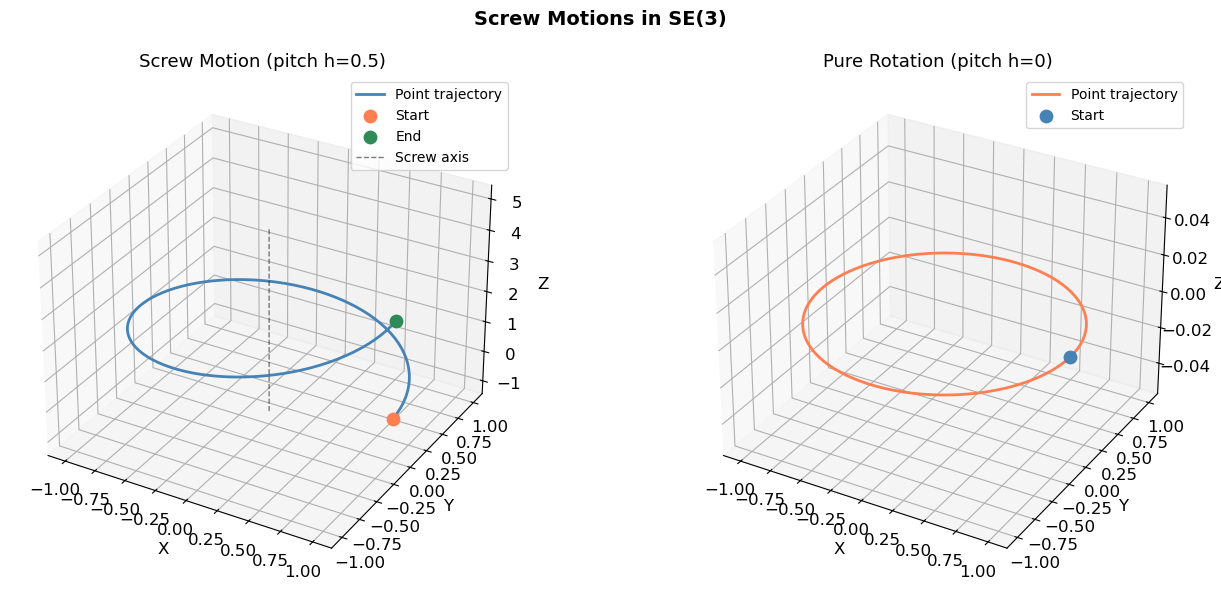

In [19]:
# =============================================================================
# Section 7: Screw Theory Visualization
# =============================================================================

# Visualize a screw motion: rotation about z-axis + translation along z
omega_screw = np.array([0, 0, 1.0])
v_screw = np.array([0, 0, 0.5])  # pitch h = 0.5
xi_screw = np.concatenate([v_screw, omega_screw])

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121, projection='3d')

# Trace the trajectory of a point under the screw motion
p0 = np.array([1, 0, 0, 1])  # homogeneous coordinates
trajectory = []
t_range = np.linspace(0, 2 * PI, 100)
for t in t_range:
    T_t = exp_se3(xi_screw * t)
    p_t = T_t @ p0
    trajectory.append(p_t[:3])

trajectory = np.array(trajectory)
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2],
        color=C_PRIMARY, linewidth=2, label='Point trajectory')
ax.scatter(*trajectory[0], color=C_SECONDARY, s=80, zorder=5, label='Start')
ax.scatter(*trajectory[-1], color=C_TERTIARY, s=80, zorder=5, label='End')

# Draw screw axis
ax.plot([0, 0], [0, 0], [-1, 5], 'k--', alpha=0.5, linewidth=1, label='Screw axis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Screw Motion (pitch h=0.5)', fontsize=13)
ax.legend(fontsize=10)

# Right panel: pure rotation (pitch = 0)
ax2 = fig.add_subplot(122, projection='3d')
xi_pure_rot = np.array([0, 0, 0, 0, 0, 1.0])
trajectory2 = []
for t in t_range:
    T_t = exp_se3(xi_pure_rot * t)
    p_t = T_t @ p0
    trajectory2.append(p_t[:3])

trajectory2 = np.array(trajectory2)
ax2.plot(trajectory2[:, 0], trajectory2[:, 1], trajectory2[:, 2],
         color=C_SECONDARY, linewidth=2, label='Point trajectory')
ax2.scatter(*trajectory2[0], color=C_PRIMARY, s=80, zorder=5, label='Start')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Pure Rotation (pitch h=0)', fontsize=13)
ax2.legend(fontsize=10)

plt.suptitle("Screw Motions in SE(3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. The Adjoint Representation of SE(3)

The **adjoint representation** $\text{Ad}_T$ of $T \in SE(3)$ is a $6 \times 6$ matrix
that transforms twists between coordinate frames:

$$
\boxed{\text{Ad}_T = \begin{bmatrix} R & [p]_\times R \\ 0 & R \end{bmatrix} \in \mathbb{R}^{6 \times 6}}
$$

where $T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix}$.

### Key Properties

1. **Group homomorphism**: $\text{Ad}_{T_1 T_2} = \text{Ad}_{T_1} \, \text{Ad}_{T_2}$
2. **Inverse**: $\text{Ad}_{T^{-1}} = (\text{Ad}_T)^{-1}$
3. **Twist transformation**: If $\mathcal{V}_b$ is a twist in body frame, then
   $\mathcal{V}_s = \text{Ad}_T \, \mathcal{V}_b$ is the same twist in space frame.

### Why It Matters

The adjoint is essential for:
- Transforming Jacobians between frames (spatial vs. body)
- The product of exponentials formula
- Computing the dynamics of articulated rigid bodies

In [20]:
# =============================================================================
# Section 8: Adjoint Representation
# =============================================================================

def adjoint_se3(T):
    """Compute the 6x6 adjoint representation of T in SE(3).

    Ad_T = [[R, [p]_x @ R],
            [0,        R  ]]

    Transforms twists from body to spatial frame.

    Args:
        T: Homogeneous transformation matrix.
            Shape: (4, 4)

    Returns:
        Ad: Adjoint matrix.
            Shape: (6, 6)
    """
    R = T[:3, :3]
    p = T[:3, 3]
    Ad = np.zeros((6, 6))
    Ad[:3, :3] = R
    Ad[:3, 3:] = hat3(p) @ R
    Ad[3:, 3:] = R
    return Ad


# === Verification: Ad_{T1 T2} == Ad_{T1} @ Ad_{T2} ===
print("=== Adjoint Representation Verification ===\n")

np.random.seed(SEED)
print("--- Ad_{T1*T2} == Ad_{T1} @ Ad_{T2} ---")
for i in range(5):
    R_a = random_rotation()
    p_a = np.random.randn(3)
    T_a = make_se3(R_a, p_a)

    R_b = random_rotation()
    p_b = np.random.randn(3)
    T_b = make_se3(R_b, p_b)

    Ad_product = adjoint_se3(T_a @ T_b)
    Ad_composed = adjoint_se3(T_a) @ adjoint_se3(T_b)

    err = norm(Ad_product - Ad_composed)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: Ad_{{T1*T2}} vs Ad_{{T1}} @ Ad_{{T2}}: max relative error = {err:.2e} [{status}]")

# Verify Ad_{T^{-1}} = (Ad_T)^{-1}
print("\n--- Ad_{T^{-1}} == (Ad_T)^{-1} ---")
for i in range(3):
    R_c = random_rotation()
    p_c = np.random.randn(3)
    T_c = make_se3(R_c, p_c)

    Ad_inv = adjoint_se3(inv_se3(T_c))
    inv_Ad = inv(adjoint_se3(T_c))

    err = norm(Ad_inv - inv_Ad)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: Ad_{{T^-1}} vs inv(Ad_T): max relative error = {err:.2e} [{status}]")

# Verify twist transformation: T @ exp(xi) @ T^{-1} = exp(Ad_T @ xi)
print("\n--- T exp(xi) T^{-1} == exp(Ad_T xi) ---")
np.random.seed(SEED + 5)
for i in range(3):
    R_d = random_rotation()
    p_d = np.random.randn(3)
    T_d = make_se3(R_d, p_d)
    xi_d = np.random.randn(6) * 0.3

    lhs = T_d @ exp_se3(xi_d) @ inv_se3(T_d)
    rhs = exp_se3(adjoint_se3(T_d) @ xi_d)

    err = norm(lhs - rhs)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: conjugation identity: max relative error = {err:.2e} [{status}]")

=== Adjoint Representation Verification ===

--- Ad_{T1*T2} == Ad_{T1} @ Ad_{T2} ---
  Test 1: Ad_{T1*T2} vs Ad_{T1} @ Ad_{T2}: max relative error = 6.19e-16 [PASS]
  Test 2: Ad_{T1*T2} vs Ad_{T1} @ Ad_{T2}: max relative error = 5.58e-16 [PASS]
  Test 3: Ad_{T1*T2} vs Ad_{T1} @ Ad_{T2}: max relative error = 9.34e-16 [PASS]
  Test 4: Ad_{T1*T2} vs Ad_{T1} @ Ad_{T2}: max relative error = 6.29e-16 [PASS]
  Test 5: Ad_{T1*T2} vs Ad_{T1} @ Ad_{T2}: max relative error = 9.82e-16 [PASS]

--- Ad_{T^{-1}} == (Ad_T)^{-1} ---
  Test 1: Ad_{T^-1} vs inv(Ad_T): max relative error = 1.78e-15 [PASS]
  Test 2: Ad_{T^-1} vs inv(Ad_T): max relative error = 1.55e-15 [PASS]
  Test 3: Ad_{T^-1} vs inv(Ad_T): max relative error = 1.58e-15 [PASS]

--- T exp(xi) T^{-1} == exp(Ad_T xi) ---
  Test 1: conjugation identity: max relative error = 4.62e-16 [PASS]
  Test 2: conjugation identity: max relative error = 5.61e-16 [PASS]
  Test 3: conjugation identity: max relative error = 1.43e-15 [PASS]


---
## 9. Application: Product of Exponentials for Forward Kinematics

### The PoE Formula

The **Product of Exponentials** (PoE) formula is an elegant alternative to
Denavit-Hartenberg parameters for robot forward kinematics.

For an $n$-joint robot with joint angles $\theta_1, \ldots, \theta_n$ and
**spatial twist axes** $\mathcal{S}_i$ at the home configuration, the forward
kinematics (spatial frame) is:

$$
\boxed{T_{sb}(\theta) = e^{[\mathcal{S}_1]\theta_1} \, e^{[\mathcal{S}_2]\theta_2} \cdots e^{[\mathcal{S}_n]\theta_n} \, M}
$$

where $M = T_{sb}(0)$ is the end-effector pose at the home configuration.

### Spatial vs Body Jacobian

The **spatial Jacobian** $J_s(\theta)$ relates joint velocities $\dot{\theta}$ to the
spatial twist:

$$
\mathcal{V}_s = J_s(\theta) \, \dot{\theta}
$$

The columns of the spatial Jacobian are the transformed screw axes:

$$
J_s = \begin{bmatrix} \mathcal{S}_1 & \text{Ad}_{e^{[S_1]\theta_1}} \mathcal{S}_2 & \cdots \end{bmatrix}
$$

The **body Jacobian** is obtained via the adjoint:

$$
J_b = \text{Ad}_{T_{sb}^{-1}} \, J_s
$$

### Example: 3R Planar Arm

We implement the PoE formula for a 3-link planar robot arm with revolute joints,
all rotating about the z-axis.

In [21]:
# =============================================================================
# Section 9: Product of Exponentials for a 3R Planar Arm
# =============================================================================

def poe_fk(screws, thetas, M):
    """Forward kinematics via the spatial Product of Exponentials formula.

    Computes T = exp(S1*theta1) @ exp(S2*theta2) @ ... @ exp(Sn*thetan) @ M

    Args:
        screws: List of 6D spatial screw axes at home configuration.
            Shape: list of (6,) arrays, length n
        thetas: Joint angles.
            Shape: (n,)
        M: End-effector pose at home configuration.
            Shape: (4, 4)

    Returns:
        T: End-effector pose.
            Shape: (4, 4)
    """
    T = np.eye(4)
    for S, theta in zip(screws, thetas):
        T = T @ exp_se3(S * theta)
    T = T @ M
    return T


def spatial_jacobian(screws, thetas):
    """Compute the spatial Jacobian for the PoE formula.

    J_s = [S1, Ad_{exp(S1*t1)} S2, Ad_{exp(S1*t1) exp(S2*t2)} S3, ...]

    Args:
        screws: List of 6D spatial screw axes.
            Shape: list of (6,) arrays, length n
        thetas: Joint angles.
            Shape: (n,)

    Returns:
        Js: Spatial Jacobian matrix.
            Shape: (6, n)
    """
    n = len(screws)
    Js = np.zeros((6, n))
    T_product = np.eye(4)

    for i in range(n):
        Js[:, i] = adjoint_se3(T_product) @ screws[i]
        T_product = T_product @ exp_se3(screws[i] * thetas[i])

    return Js


def body_jacobian(screws, thetas, M):
    """Compute the body Jacobian from the spatial Jacobian.

    J_b = Ad_{T^{-1}} @ J_s

    Args:
        screws: List of 6D spatial screw axes.
            Shape: list of (6,) arrays, length n
        thetas: Joint angles.
            Shape: (n,)
        M: End-effector pose at home configuration.
            Shape: (4, 4)

    Returns:
        Jb: Body Jacobian matrix.
            Shape: (6, n)
    """
    Js = spatial_jacobian(screws, thetas)
    T = poe_fk(screws, thetas, M)
    Ad_inv = adjoint_se3(inv_se3(T))
    return Ad_inv @ Js


# =============================================================================
# 3R Planar Arm Setup
# =============================================================================
# Link lengths
L1, L2, L3 = 1.0, 0.8, 0.6

# Home configuration: all joints at zero, arm fully extended along x
# Joint 1 at origin, rotating about z
# Joint 2 at (L1, 0, 0), rotating about z
# Joint 3 at (L1+L2, 0, 0), rotating about z

# Spatial screw axes (all revolute about z-axis)
# For revolute joint: S = [-omega x q; omega] = [v; omega]
# omega = [0, 0, 1] for all joints

S1 = np.array([0, 0, 0, 0, 0, 1])  # joint at origin: v = -omega x 0 = 0
S2 = np.array([0, -L1, 0, 0, 0, 1])  # v = -omega x q = -[0,0,1] x [L1,0,0] = [0,-L1,0]
S3 = np.array([0, -(L1 + L2), 0, 0, 0, 1])  # v = -[0,0,1] x [L1+L2,0,0] = [0,-(L1+L2),0]

screws = [S1, S2, S3]

# End-effector at home
M_home = make_se3(np.eye(3), np.array([L1 + L2 + L3, 0, 0]))

# Test configuration
thetas_test = np.array([PI/4, PI/6, -PI/3])
T_ee = poe_fk(screws, thetas_test, M_home)

print("=== 3R Planar Arm Forward Kinematics (PoE) ===\n")
print(f"Joint angles: theta = [{np.degrees(thetas_test[0]):.1f}, "
      f"{np.degrees(thetas_test[1]):.1f}, {np.degrees(thetas_test[2]):.1f}] deg")
print(f"\nEnd-effector pose T =")
print(np.round(T_ee, 4))

# Verify valid SE(3)
valid, details = is_valid_se3(T_ee)
status = "PASS" if valid else "FAIL"
print(f"\nFK produces valid SE(3): ortho={details['ortho']:.2e}, "
      f"det={details['det']:.2e} [{status}]")

# Compare with direct geometric computation
total_angle_1 = thetas_test[0]
total_angle_2 = thetas_test[0] + thetas_test[1]
total_angle_3 = thetas_test[0] + thetas_test[1] + thetas_test[2]
x_ee = (L1 * np.cos(total_angle_1) + L2 * np.cos(total_angle_2)
        + L3 * np.cos(total_angle_3))
y_ee = (L1 * np.sin(total_angle_1) + L2 * np.sin(total_angle_2)
        + L3 * np.sin(total_angle_3))

print(f"\nPoE position:       ({T_ee[0,3]:.6f}, {T_ee[1,3]:.6f})")
print(f"Geometric position: ({x_ee:.6f}, {y_ee:.6f})")
pos_err = np.sqrt((T_ee[0, 3] - x_ee)**2 + (T_ee[1, 3] - y_ee)**2)
status = "PASS" if pos_err < PASS_THRESHOLD else "FAIL"
print(f"Position error:      max relative error = {pos_err:.2e} [{status}]")

=== 3R Planar Arm Forward Kinematics (PoE) ===

Joint angles: theta = [45.0, 30.0, -60.0] deg

End-effector pose T =
[[ 0.9659 -0.2588  0.      1.4937]
 [ 0.2588  0.9659  0.      1.6351]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]

FK produces valid SE(3): ortho=1.92e-17, det=1.11e-16 [PASS]

PoE position:       (1.493718, 1.635139)
Geometric position: (1.493718, 1.635139)
Position error:      max relative error = 2.22e-16 [PASS]


In [22]:
# =============================================================================
# Section 9: Spatial vs Body Jacobian Comparison
# =============================================================================

Js = spatial_jacobian(screws, thetas_test)
Jb = body_jacobian(screws, thetas_test, M_home)

print("=== Jacobian Analysis ===\n")
print("Spatial Jacobian J_s =")
print(np.round(Js, 4))
print("\nBody Jacobian J_b =")
print(np.round(Jb, 4))

# Verify relationship: J_b = Ad_{T^{-1}} @ J_s
T_ee = poe_fk(screws, thetas_test, M_home)
Jb_from_Js = adjoint_se3(inv_se3(T_ee)) @ Js
err_jac = norm(Jb - Jb_from_Js)
status = "PASS" if err_jac < PASS_THRESHOLD else "FAIL"
print(f"\nJ_b == Ad_{{T^-1}} @ J_s:         max relative error = {err_jac:.2e} [{status}]")

=== Jacobian Analysis ===

Spatial Jacobian J_s =
[[ 0.      0.7071  1.4798]
 [ 0.     -0.7071 -0.9142]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]
 [ 1.      1.      1.    ]]

Body Jacobian J_b =
[[-1.1928 -0.6928 -0.    ]
 [ 1.866   1.      0.6   ]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]
 [ 1.      1.      1.    ]]

J_b == Ad_{T^-1} @ J_s:         max relative error = 0.00e+00 [PASS]


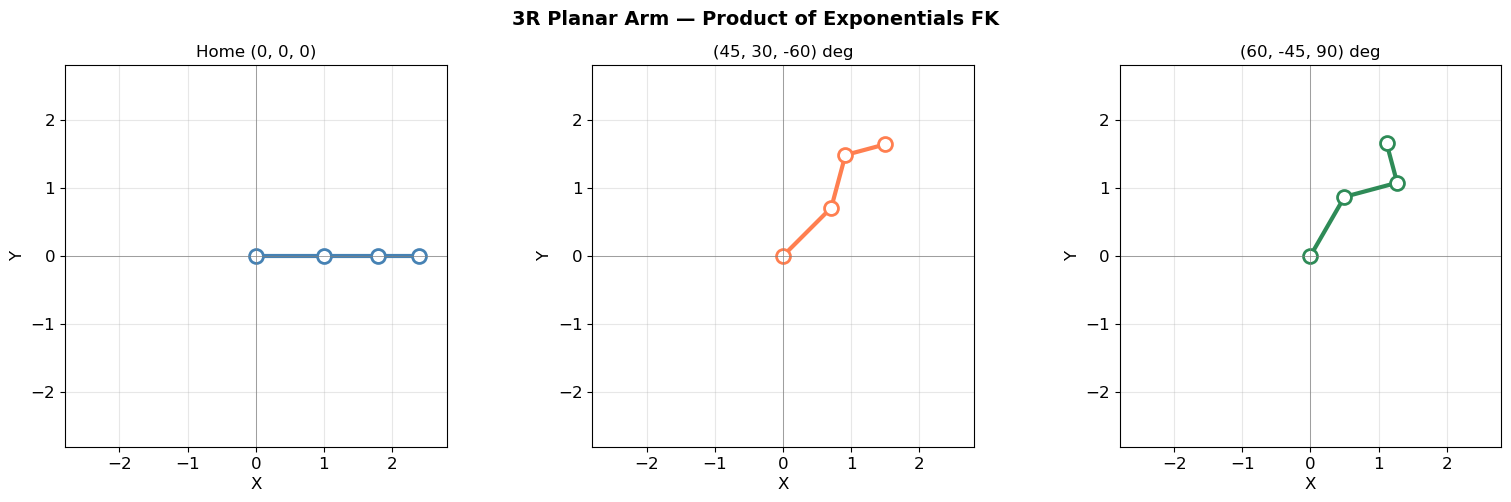

In [23]:
# =============================================================================
# Section 9: Visualization of the 3R Planar Arm
# =============================================================================

def plot_planar_arm(ax, screws, thetas, M, color=C_PRIMARY, label=None, alpha=1.0):
    """Plot a planar arm configuration.

    Args:
        ax: Matplotlib axis.
        screws: List of spatial screw axes.
        thetas: Joint angles.
            Shape: (n,)
        M: Home pose.
            Shape: (4, 4)
        color: Line color.
        label: Legend label.
        alpha: Transparency.
    """
    # Compute joint positions
    positions = [np.array([0, 0])]
    T = np.eye(4)
    for i, (S, theta) in enumerate(zip(screws, thetas)):
        T = T @ exp_se3(S * theta)
        if i < len(screws) - 1:
            # Position of next joint in the chain
            partial_M_pos = np.zeros(3)
            for j in range(i + 1):
                if j == 0:
                    partial_M_pos[0] = L1
                elif j == 1:
                    partial_M_pos[0] = L1 + L2

            # Just use FK up to this joint
            pass

    # Simpler approach: compute joint positions geometrically for planar case
    angles_cum = np.cumsum(thetas)
    links = [L1, L2, L3]
    x, y = 0, 0
    positions = [(x, y)]
    for i, (link, angle) in enumerate(zip(links, angles_cum)):
        x += link * np.cos(angle)
        y += link * np.sin(angle)
        positions.append((x, y))

    positions = np.array(positions)
    ax.plot(positions[:, 0], positions[:, 1], 'o-', color=color,
            linewidth=3, markersize=10, alpha=alpha, label=label,
            markerfacecolor='white', markeredgewidth=2, markeredgecolor=color)
    return positions


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Configuration 1: Various joint angles
configs = [
    (np.array([0, 0, 0]), "Home (0, 0, 0)"),
    (np.array([PI/4, PI/6, -PI/3]), "(45, 30, -60) deg"),
    (np.array([PI/3, -PI/4, PI/2]), "(60, -45, 90) deg"),
]

colors_configs = [C_PRIMARY, C_SECONDARY, C_TERTIARY]

for ax_idx, (thetas_cfg, cfg_label) in enumerate(configs):
    ax = axes[ax_idx]
    positions = plot_planar_arm(ax, screws, thetas_cfg, M_home,
                                color=colors_configs[ax_idx], label=cfg_label)
    ax.set_xlim([-2.8, 2.8])
    ax.set_ylim([-2.8, 2.8])
    ax.set_aspect('equal')
    ax.set_title(cfg_label, fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)

plt.suptitle("3R Planar Arm — Product of Exponentials FK", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

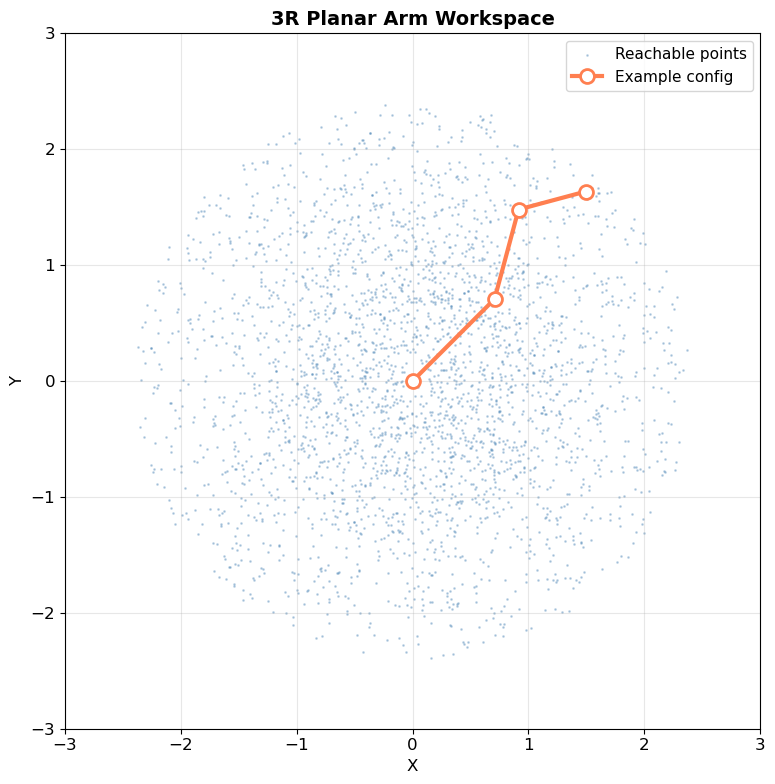

In [24]:
# =============================================================================
# Section 9: Workspace Visualization
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

np.random.seed(SEED)
n_samples = 3000
ee_positions = []

for _ in range(n_samples):
    thetas_rand = np.random.uniform(-PI, PI, 3)
    T_rand = poe_fk(screws, thetas_rand, M_home)
    ee_positions.append([T_rand[0, 3], T_rand[1, 3]])

ee_positions = np.array(ee_positions)

ax.scatter(ee_positions[:, 0], ee_positions[:, 1], s=1, alpha=0.3,
           color=C_PRIMARY, label='Reachable points')

# Draw the arm at a specific configuration
thetas_show = np.array([PI/4, PI/6, -PI/3])
plot_planar_arm(ax, screws, thetas_show, M_home, color=C_SECONDARY, label='Example config')

ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_aspect('equal')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('3R Planar Arm Workspace', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Extensions and Advanced Topics

### 10.1 Baker-Campbell-Hausdorff (BCH) Formula

For matrix Lie algebras, $e^X e^Y \neq e^{X+Y}$ in general. The BCH formula gives
the correction:

$$
\log(e^X e^Y) = X + Y + \frac{1}{2}[X, Y] + \frac{1}{12}([X, [X, Y]] - [Y, [X, Y]]) + \cdots
$$

The first-order approximation $\log(e^X e^Y) \approx X + Y + \frac{1}{2}[X, Y]$ is
useful for small perturbations.

### 10.2 Lie Group Integration

For simulating rigid body dynamics, one needs to integrate on the group manifold.
A simple approach is the **exponential Euler** method:

$$
R_{k+1} = R_k \cdot \exp([\omega_k]_\times \, \Delta t)
$$

This preserves the group structure exactly (the result is always a valid rotation),
unlike naive Euler integration $R_{k+1} = R_k + \dot{R}_k \Delta t$.

### 10.3 Quaternions as Double Cover of SO(3)

Unit quaternions $q = (w, x, y, z)$ with $\|q\| = 1$ form a **double cover** of SO(3):
both $q$ and $-q$ represent the same rotation. The map from axis-angle to quaternion is:

$$
q = \left(\cos\frac{\theta}{2}, \; \hat{\omega} \sin\frac{\theta}{2}\right)
$$

Quaternions are preferred in practice for:
- Numerical stability (4 parameters vs 9 for a matrix)
- Efficient composition and interpolation (SLERP)
- No gimbal lock (unlike Euler angles)

In [25]:
# =============================================================================
# Section 10: BCH Formula Verification
# =============================================================================

def bch_first_order(X, Y):
    """First-order BCH approximation: log(exp(X) exp(Y)) ~ X + Y + 0.5[X,Y].

    Args:
        X: Element of the Lie algebra (as a vector).
            Shape: (3,)
        Y: Element of the Lie algebra (as a vector).
            Shape: (3,)

    Returns:
        Z: BCH approximation of log(exp(X) exp(Y)).
            Shape: (3,)
    """
    bracket = np.cross(X, Y)  # For so(3), Lie bracket = cross product
    return X + Y + 0.5 * bracket

print("=== BCH Formula Verification ===\n")

# Compare BCH approximation with exact result for small rotations
scales = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
np.random.seed(SEED)
omega_x = np.random.randn(3)
omega_y = np.random.randn(3)

print(f"{'Scale':>8s}  {'BCH Error':>12s}  {'Quality':>10s}")
print("-" * 35)
for scale in scales:
    X = omega_x * scale
    Y = omega_y * scale

    # Exact
    R_exact = exp_so3(X) @ exp_so3(Y)
    omega_exact = log_so3(R_exact)

    # BCH approximation
    omega_bch = bch_first_order(X, Y)

    err = norm(omega_exact - omega_bch)
    quality = "Excellent" if err < 1e-4 else "Good" if err < 1e-2 else "Poor"
    print(f"{scale:8.3f}  {err:12.2e}  {quality:>10s}")

print("\n(BCH first-order is O(||X||^2 + ||Y||^2), so error grows with scale)")

=== BCH Formula Verification ===

   Scale     BCH Error     Quality
-----------------------------------
   0.010      1.27e-07   Excellent
   0.050      1.59e-05   Excellent
   0.100      1.27e-04        Good
   0.200      1.02e-03        Good
   0.500      1.65e-02        Poor
   1.000      1.48e-01        Poor

(BCH first-order is O(||X||^2 + ||Y||^2), so error grows with scale)


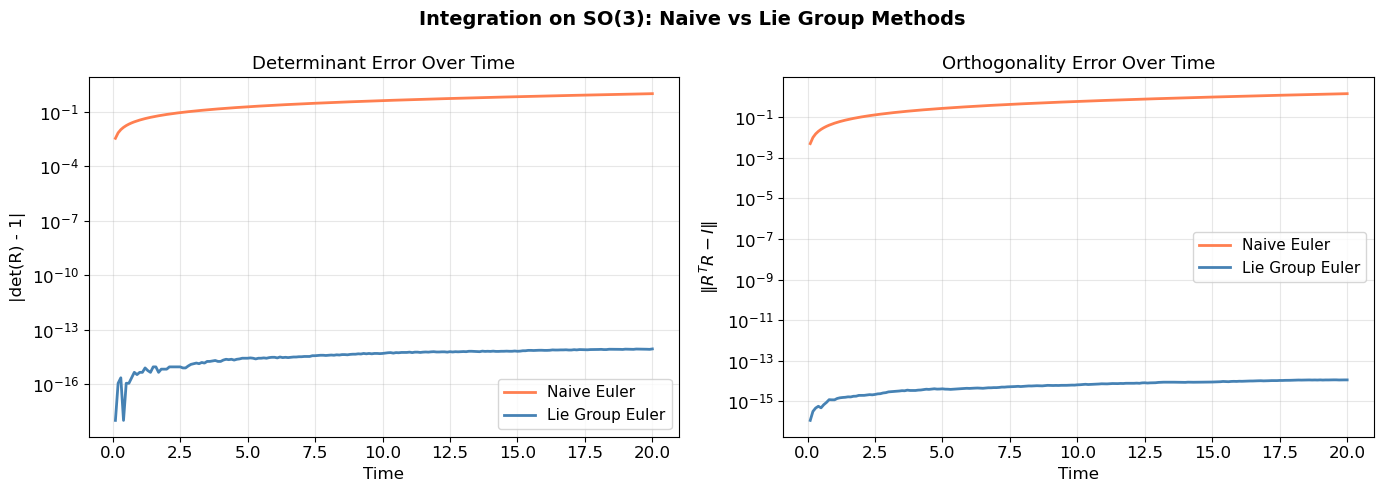

After 200 steps (t = 20.0):
  Naive Euler:     det error = 1.01e+00, ortho error = 1.43e+00
  Lie Group Euler: det error = 8.66e-15, ortho error = 1.13e-14


In [26]:
# =============================================================================
# Section 10: Lie Group Integration — Spinning Top
# =============================================================================

def euler_naive(R, omega, dt):
    """Naive Euler integration (violates group structure).

    Args:
        R: Current rotation.
            Shape: (3, 3)
        omega: Angular velocity.
            Shape: (3,)
        dt: Time step.

    Returns:
        R_next: Updated rotation (NOT necessarily in SO(3)).
            Shape: (3, 3)
    """
    R_dot = hat3(omega) @ R
    return R + R_dot * dt


def euler_lie(R, omega, dt):
    """Lie group (exponential) Euler integration (preserves SO(3)).

    Args:
        R: Current rotation.
            Shape: (3, 3)
        omega: Angular velocity.
            Shape: (3,)
        dt: Time step.

    Returns:
        R_next: Updated rotation (always in SO(3)).
            Shape: (3, 3)
    """
    return R @ exp_so3(omega * dt)


# Simulate a constant-angular-velocity rotation
omega_sim = np.array([0.1, 0.5, 0.3])
dt = 0.1
n_steps = 200
R_naive = np.eye(3)
R_lie = np.eye(3)

det_errors_naive = []
det_errors_lie = []
ortho_errors_naive = []
ortho_errors_lie = []

for step in range(n_steps):
    R_naive = euler_naive(R_naive, omega_sim, dt)
    R_lie = euler_lie(R_lie, omega_sim, dt)

    det_errors_naive.append(abs(det(R_naive) - 1.0))
    det_errors_lie.append(abs(det(R_lie) - 1.0))
    ortho_errors_naive.append(norm(R_naive.T @ R_naive - np.eye(3)))
    ortho_errors_lie.append(norm(R_lie.T @ R_lie - np.eye(3)))

t_axis = np.arange(1, n_steps + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(t_axis, det_errors_naive, color=C_SECONDARY, label='Naive Euler', linewidth=2)
axes[0].semilogy(t_axis, np.maximum(det_errors_lie, 1e-18), color=C_PRIMARY, label='Lie Group Euler', linewidth=2)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('|det(R) - 1|')
axes[0].set_title('Determinant Error Over Time', fontsize=13)
axes[0].legend(fontsize=11)

axes[1].semilogy(t_axis, ortho_errors_naive, color=C_SECONDARY, label='Naive Euler', linewidth=2)
axes[1].semilogy(t_axis, np.maximum(ortho_errors_lie, 1e-18), color=C_PRIMARY, label='Lie Group Euler', linewidth=2)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('$\|R^T R - I\|$')
axes[1].set_title('Orthogonality Error Over Time', fontsize=13)
axes[1].legend(fontsize=11)

plt.suptitle("Integration on SO(3): Naive vs Lie Group Methods", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"After {n_steps} steps (t = {n_steps*dt:.1f}):")
print(f"  Naive Euler:     det error = {det_errors_naive[-1]:.2e}, ortho error = {ortho_errors_naive[-1]:.2e}")
print(f"  Lie Group Euler: det error = {det_errors_lie[-1]:.2e}, ortho error = {ortho_errors_lie[-1]:.2e}")

In [27]:
# =============================================================================
# Section 10: Quaternion Double Cover of SO(3)
# =============================================================================

def axis_angle_to_quat(omega):
    """Convert axis-angle to unit quaternion.

    q = (cos(theta/2), omega_hat * sin(theta/2))

    Args:
        omega: Rotation vector (axis * angle).
            Shape: (3,)

    Returns:
        q: Unit quaternion [w, x, y, z].
            Shape: (4,)
    """
    theta = norm(omega)
    if theta < TOLERANCE:
        return np.array([1.0, 0, 0, 0])
    axis = omega / theta
    half_theta = theta / 2.0
    return np.array([np.cos(half_theta),
                     *(axis * np.sin(half_theta))])


def quat_to_rotation(q):
    """Convert unit quaternion to rotation matrix.

    Args:
        q: Unit quaternion [w, x, y, z].
            Shape: (4,)

    Returns:
        R: Rotation matrix.
            Shape: (3, 3)
    """
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - z*w),     2*(x*z + y*w)],
        [    2*(x*y + z*w), 1 - 2*(x*x + z*z),     2*(y*z - x*w)],
        [    2*(x*z - y*w),     2*(y*z + x*w), 1 - 2*(x*x + y*y)]
    ])


# Verify: quaternion -> rotation vs exponential map
print("=== Quaternion Double Cover Verification ===\n")

np.random.seed(SEED)
print("--- Quaternion vs exp_so3 ---")
for i in range(5):
    omega_test = np.random.randn(3) * np.random.uniform(0.1, PI * 0.9)
    R_exp = exp_so3(omega_test)
    q = axis_angle_to_quat(omega_test)
    R_quat = quat_to_rotation(q)

    err = norm(R_exp - R_quat)
    status = "PASS" if err < PASS_THRESHOLD else "FAIL"
    print(f"  Test {i+1}: exp_so3 vs quaternion: max relative error = {err:.2e} [{status}]")

# Demonstrate double cover: q and -q give the same rotation
print("\n--- Double cover: q and -q give same R ---")
omega_dc = np.array([0.5, 0.3, 0.7])
q_pos = axis_angle_to_quat(omega_dc)
q_neg = -q_pos

R_pos = quat_to_rotation(q_pos)
R_neg = quat_to_rotation(q_neg)

err_dc = norm(R_pos - R_neg)
status = "PASS" if err_dc < PASS_THRESHOLD else "FAIL"
print(f"  R(q) == R(-q):                 max relative error = {err_dc:.2e} [{status}]")
print(f"  q  = {np.round(q_pos, 4)}")
print(f"  -q = {np.round(q_neg, 4)}")
print(f"  (Different quaternions, same rotation)")

=== Quaternion Double Cover Verification ===

--- Quaternion vs exp_so3 ---
  Test 1: exp_so3 vs quaternion: max relative error = 1.72e-16 [PASS]
  Test 2: exp_so3 vs quaternion: max relative error = 6.43e-16 [PASS]
  Test 3: exp_so3 vs quaternion: max relative error = 1.57e-16 [PASS]
  Test 4: exp_so3 vs quaternion: max relative error = 4.65e-16 [PASS]
  Test 5: exp_so3 vs quaternion: max relative error = 5.55e-16 [PASS]

--- Double cover: q and -q give same R ---
  R(q) == R(-q):                 max relative error = 0.00e+00 [PASS]
  q  = [0.898  0.2414 0.1449 0.338 ]
  -q = [-0.898  -0.2414 -0.1449 -0.338 ]
  (Different quaternions, same rotation)


---
## Summary

This notebook developed the theory and implementation of two fundamental Lie groups
in robotics:

| Concept | Group | Algebra | Dim | Application |
|---------|-------|---------|-----|-------------|
| Rotations | $SO(3)$ | $\mathfrak{so}(3)$ | 3 | Orientation |
| Rigid motions | $SE(3)$ | $\mathfrak{se}(3)$ | 6 | Pose (position + orientation) |

**Key maps implemented:**

| Function | Map | Purpose |
|----------|-----|---------|
| `hat3` / `vee3` | $\mathbb{R}^3 \leftrightarrow \mathfrak{so}(3)$ | Vector ↔ skew-symmetric matrix |
| `exp_so3` | $\mathfrak{so}(3) \to SO(3)$ | Rodrigues' formula |
| `log_so3` | $SO(3) \to \mathfrak{so}(3)$ | Inverse of exponential |
| `hat6` / `vee6` | $\mathbb{R}^6 \leftrightarrow \mathfrak{se}(3)$ | Twist ↔ 4×4 matrix |
| `exp_se3` | $\mathfrak{se}(3) \to SE(3)$ | Twist exponential |
| `log_se3` | $SE(3) \to \mathfrak{se}(3)$ | Inverse of twist exponential |
| `adjoint_se3` | $SE(3) \to \mathbb{R}^{6 \times 6}$ | Frame transformation of twists |
| `poe_fk` | $\theta \mapsto T$ | Forward kinematics via PoE |

**The Lie group perspective** unifies rotations, rigid motions, kinematics, and dynamics
under a single elegant mathematical framework. The exponential map provides
singularity-free local parameterization, while the adjoint representation enables
systematic frame transformations.